## GAN FOR CIFAR10

In [1]:
#data loafinh + preprocessing

import numpy as np
from tensorflow.keras.datasets import cifar10

(X_train,_),(_,_)=cifar10.load_data()

# normalize [-1,1]
X_train=(X_train-127.5)/127.5

# reshape
X_train=np.expand_dims(X_train, axis=-1)

print(X_train.shape)

(50000, 32, 32, 3, 1)


In [3]:
# imports used here
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, Conv2DTranspose

def build_generator():
    model = Sequential()

    model.add(Dense(128 * 8 * 8, activation="relu", input_dim=100))
    model.add(Reshape((8, 8, 128)))

    model.add(Conv2DTranspose(128, (4,4), strides=2, padding='same', activation='relu'))
    model.add(Conv2DTranspose(64, (4,4), strides=2, padding='same', activation='relu'))
    model.add(Conv2DTranspose(3, (3,3), activation='tanh', padding='same'))

    return model

In [4]:
# imports used here
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, LeakyReLU

def build_discriminator():
    model = Sequential()

    model.add(Conv2D(64, (3,3), strides=2, padding='same', input_shape=(32,32,3)))
    model.add(LeakyReLU(0.2))

    model.add(Conv2D(128, (3,3), strides=2, padding='same'))
    model.add(LeakyReLU(0.2))

    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model

In [5]:
# imports used here
from tensorflow.keras.models import Sequential

def build_gan(generator, discriminator):
    discriminator.trainable = False
    model = Sequential([generator, discriminator])
    return model

In [6]:
# imports used here
from tensorflow.keras.optimizers import Adam

generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(optimizer=Adam(0.0002, 0.5),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

gan = build_gan(generator, discriminator)

gan.compile(optimizer=Adam(0.0002, 0.5),
            loss='binary_crossentropy')

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
def get_real_images(batch_size):
    import numpy as np

    idx = np.random.randint(0, X_train.shape[0], batch_size)
    imgs = X_train[idx]

    if len(imgs.shape) == 5:
        imgs = imgs.squeeze()

    return imgs

In [12]:
def save_images(epoch):
    import numpy as np
    import matplotlib.pyplot as plt

    noise = np.random.normal(0, 1, (25, 100))
    gen_images = generator.predict(noise, verbose=0)

    # rescale to [0,1]
    gen_images = 0.5 * gen_images + 0.5

    plt.figure(figsize=(5,5))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.imshow(gen_images[i])  # RGB fix
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [13]:
def train_gan(epochs=1000, batch_size=64, save_interval=200):
    import numpy as np

    d_losses = []
    g_losses = []

    for epoch in range(epochs):

        # --- Train Discriminator ---
        real_images = get_real_images(batch_size)

        noise = np.random.normal(0, 1, (batch_size, 100))
        fake_images = generator.predict(noise, verbose=0)

        X = np.concatenate([real_images, fake_images])
        y = np.concatenate([np.ones(batch_size), np.zeros(batch_size)])

        d_loss, d_acc = discriminator.train_on_batch(X, y)

        # --- Train Generator ---
        noise = np.random.normal(0, 1, (batch_size, 100))
        y_gen = np.ones(batch_size)

        g_loss = gan.train_on_batch(noise, y_gen)

        d_losses.append(d_loss)
        g_losses.append(g_loss)

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | D Loss: {d_loss:.4f}, Acc: {d_acc:.4f} | G Loss: {g_loss:.4f}")

        if epoch % save_interval == 0:
            save_images(epoch)

    return d_losses, g_losses

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.6836, Acc: 0.5312 | G Loss: 0.6928


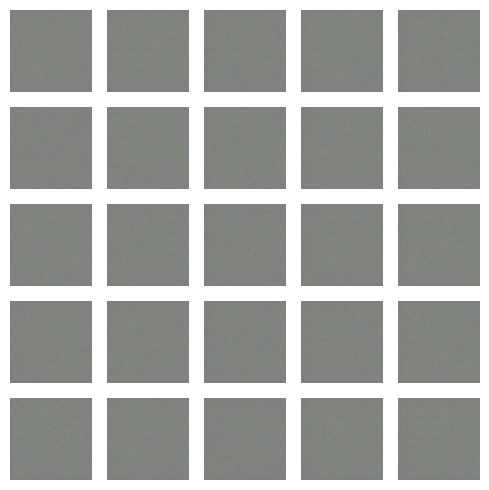

Epoch 100 | D Loss: 0.9944, Acc: 0.3675 | G Loss: 0.3540
Epoch 200 | D Loss: 1.3030, Acc: 0.3643 | G Loss: 0.2203


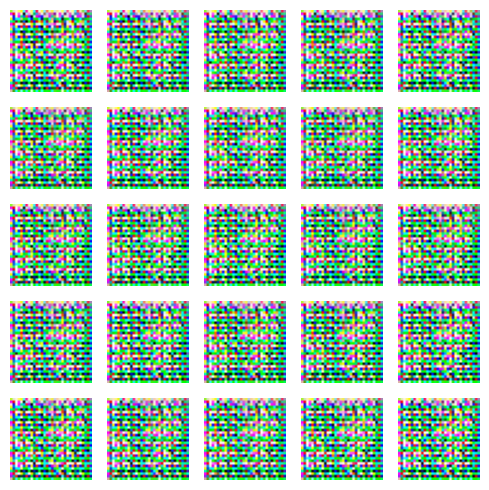

Epoch 300 | D Loss: 1.5286, Acc: 0.3639 | G Loss: 0.1599
Epoch 400 | D Loss: 1.6906, Acc: 0.3630 | G Loss: 0.1265


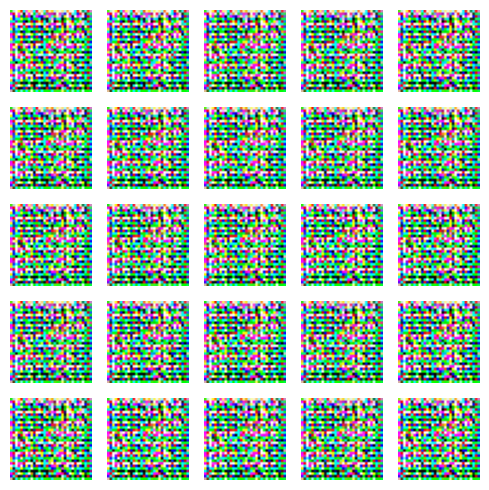

Epoch 500 | D Loss: 1.8134, Acc: 0.3635 | G Loss: 0.1052
Epoch 600 | D Loss: 1.9112, Acc: 0.3629 | G Loss: 0.0904


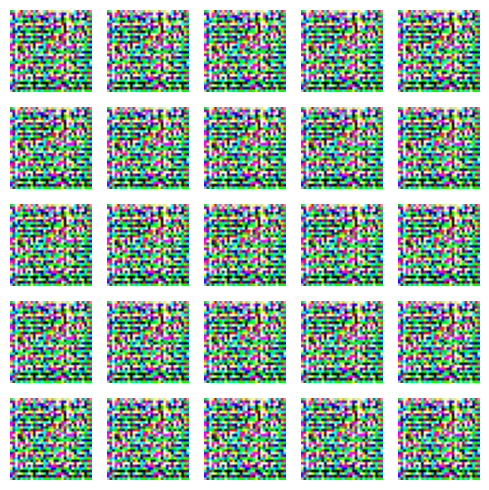

Epoch 700 | D Loss: 1.9921, Acc: 0.3624 | G Loss: 0.0795
Epoch 800 | D Loss: 2.0612, Acc: 0.3626 | G Loss: 0.0711


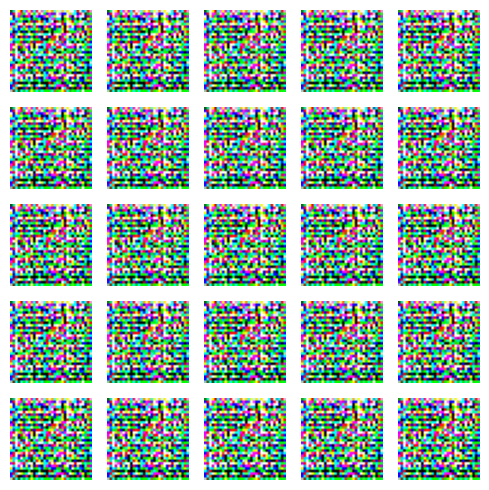

Epoch 900 | D Loss: 2.1215, Acc: 0.3622 | G Loss: 0.0644


In [14]:
d_losses, g_losses = train_gan(epochs=1000, batch_size=64)

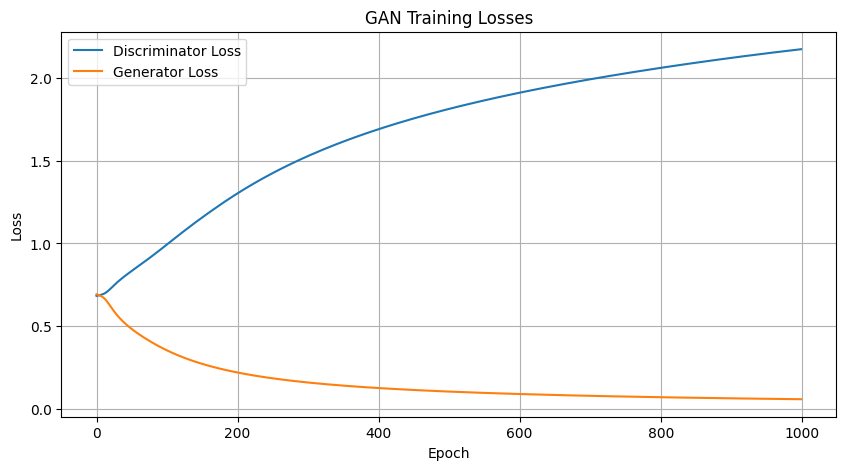

In [15]:
# imports used here
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')

plt.title('GAN Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)
plt.show()

## GAN FOR MNIST

In [ ]:
#data loafinh + preprocessing

import numpy as np
from tensorflow.keras.datasets import mnist

(X_train,_),(_,_)=mnist.load_data()

# normalize [-1,1]
X_train=(X_train-127.5)/127.5

# reshape
X_train=np.expand_dims(X_train, axis=-1)

print(X_train.shape)

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X_train, test_size=0.1, random_state=42)

In [3]:
#generator model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, BatchNormalization, Conv2DTranspose, LeakyReLU

def generator():
    model=Sequential()
    model.add(Dense(128*7*7, input_dim=100))
    model.add(LeakyReLU(0.2))
    model.add(BatchNormalization())
    model.add(Reshape((7,7,128)))
    model.add(Conv2DTranspose(64,3,strides=2,padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Conv2DTranspose(1,3,strides=2,padding='same',activation='tanh'))
    return model

gen=generator()
gen.summary()

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 6272)                │         633,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 6272)                │          25,088 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 14, 14, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 28, 28, 1)           │             577 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 732,929 (2.80 MB)

 Trainable params: 720,385 (2.75 MB)

 Non-trainable params: 12,544 (49.00 KB)

In [4]:
#discriminator

from tensorflow.keras.layers import Conv2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

def discrim():
    model=Sequential()
    
    model.add(Conv2D(64,3,strides=2,input_shape=(28,28,1)))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))
    
    model.add(Flatten())
    model.add(Dense(1,activation='sigmoid'))
    
    model.compile(optimizer=Adam(0.0002), loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

disc=discrim()
disc.summary()

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 13, 13, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 10816)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │          10,817 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,457 (44.75 KB)

 Trainable params: 11,457 (44.75 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#combined gan

def gan_model(gen,disc):
    disc.trainable=False
    model=Sequential([gen,disc])
    model.compile(loss='binary_crossentropy', optimizer=Adam(0.0002))
    return model

gan=gan_model(gen,disc)

In [9]:
#training

import numpy as np
epochs=4000
batch_size=32
half=batch_size//2

for e in range(epochs):
    #train disc

    for _ in range(2):
        idx=np.random.randint(0, X_train.shape[0], half)
        real=X_train[idx]
    
        noise=np.random.normal(0,1,(half,100))
        fake=gen.predict(noise, verbose=0)
    
        real_labels = np.ones((half,1)) * 0.9
        fake_labels = np.zeros((half,1))
        
        d_loss_real = disc.train_on_batch(real, real_labels)
        d_loss_fake = disc.train_on_batch(fake, fake_labels)

    #train generator
    noise=np.random.normal(0,1,(batch_size,100))
    g_loss=gan.train_on_batch(noise, np.ones((batch_size,1)))

    if e%200==0:
        print(f"epoch {e} | d loss: {d_loss_real[0]} | g loss: {g_loss}")

epoch 0 | d loss: 2.4423012733459473 | g loss: 0.16676034033298492
epoch 200 | d loss: 1.8354253768920898 | g loss: 0.15346835553646088
epoch 400 | d loss: 1.8516448736190796 | g loss: 0.14252173900604248
epoch 600 | d loss: 1.8676726818084717 | g loss: 0.13335120677947998
epoch 800 | d loss: 1.8829092979431152 | g loss: 0.12554563581943512
epoch 1000 | d loss: 1.8971587419509888 | g loss: 0.11882324516773224
epoch 1200 | d loss: 1.9098711013793945 | g loss: 0.11296124756336212
epoch 1400 | d loss: 1.9214907884597778 | g loss: 0.10781127214431763
epoch 1600 | d loss: 1.9320521354675293 | g loss: 0.10325846076011658
epoch 1800 | d loss: 1.9416497945785522 | g loss: 0.09920044243335724
epoch 2000 | d loss: 1.9499731063842773 | g loss: 0.09556308388710022
epoch 2200 | d loss: 1.9579137563705444 | g loss: 0.0922890305519104
epoch 2400 | d loss: 1.965132474899292 | g loss: 0.08931995928287506
epoch 2600 | d loss: 1.971665620803833 | g loss: 0.08661841601133347
epoch 2800 | d loss: 1.9777913

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


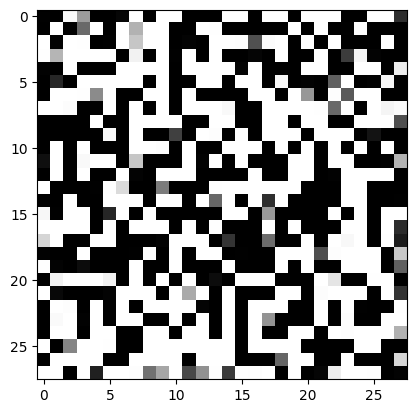

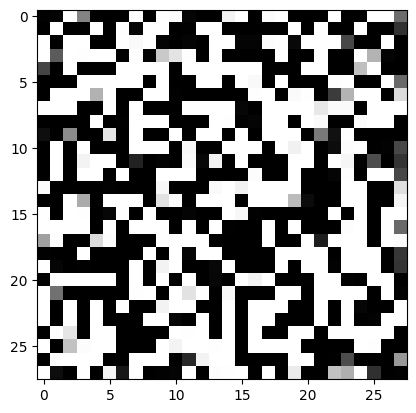

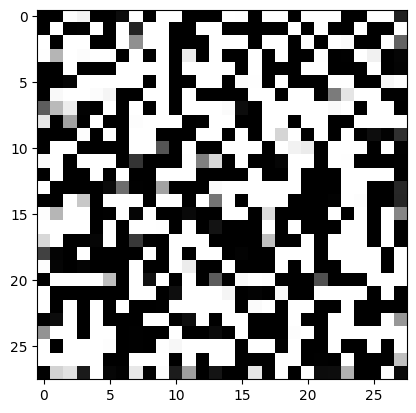

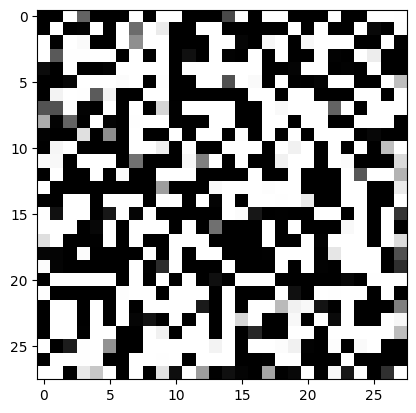

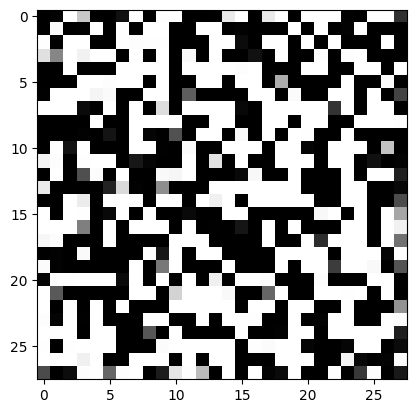

In [10]:
import matplotlib.pyplot as plt

noise=np.random.normal(0,1,(5,100))
generated=gen.predict(noise)

for i in range(5):
    plt.imshow(generated[i].reshape(28,28), cmap='gray')
    plt.show()

In [11]:
#eval

noise=np.random.normal(0,1,(100,100))
fake=gen.predict(noise)

real_labels=np.ones((100,1))
fake_labels=np.zeros((100,1))

d_loss_real=disc.evaluate(X_test[:100], real_labels, verbose=0)
d_loss_fake=disc.evaluate(fake, fake_labels, verbose=0)

print("real acc:", d_loss_real[1])
print("fake acc:", d_loss_fake[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
real acc: 0.6200000047683716
fake acc: 0.0
